
# Price Optimization Model for e‑Commerce

This notebook estimates **price elasticity**, builds a **demand model**, and computes **revenue/profit‑optimal prices** for multiple products using a realistic synthetic dataset.

**You will see:**
1) Load & preview data  
2) Explore relationships (price  demand)  
3) Estimate elasticities via a **log‑log demand model** (Linear Regression on log variables)  
4) Build a richer **ML demand model** (Gradient Boosting) for prediction  
5) Compute **profit‑optimal prices** with constraints  
6) Business‑friendly summary of recommended prices per product


In [2]:

# 1) Imports & data load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (6,4)

csv_path = "synthetic_ecommerce_price_optimization.csv"
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
display(df.head(10))


Shape: (1825, 10)


,date_index,product,price,competitor_price,marketing_spend,visibility_index,units_sold,revenue,profit,unit_cost
0,0,AlphaWatch,81.13,81.45,152.33,0.768,6,486.81,246.81,40
1,1,AlphaWatch,77.49,55.66,46.03,1.023,4,309.95,149.95,40
2,2,AlphaWatch,74.88,71.98,38.51,1.073,5,374.38,174.38,40
3,3,AlphaWatch,84.06,63.82,4.36,1.023,1,84.06,44.06,40
4,4,AlphaWatch,83.67,78.50,26.41,0.553,6,502.03,262.03,40
5,5,AlphaWatch,86.80,70.35,8.89,0.824,1,86.80,46.80,40
6,6,AlphaWatch,91.18,71.17,64.47,1.278,4,364.71,204.71,40
7,7,AlphaWatch,96.99,89.40,33.94,0.857,5,484.94,284.94,40
8,8,AlphaWatch,75.15,64.01,14.14,1.328,3,225.45,105.45,40
9,9,AlphaWatch,68.88,98.09,64.06,0.774,7,482.18,202.18,40


            price  units_sold  revenue   profit
product                                        
AlphaWatch  80.36        3.59   280.33   136.88
BetaBuds    65.93       12.99   820.02   495.16
DeltaDock   71.72        1.47   101.75    57.78
EpsilonCam  95.86        3.22   299.84   122.78
GammaBand   58.30       38.83  2153.36  1454.37


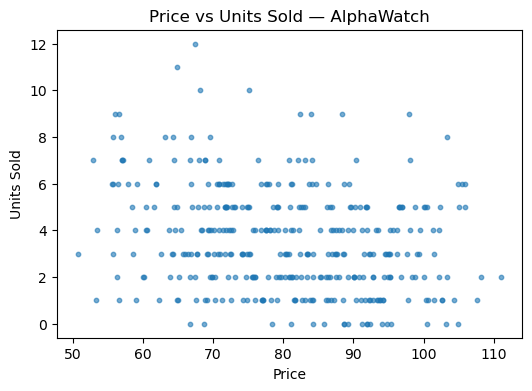

In [4]:
# 2) Quick EDA: basic summaries
print(df.groupby("product")[["price", "units_sold", "revenue", "profit"]]
      .mean()
      .round(2))

# Relationship glimpse: price vs units_sold (one product example)
prod_example = df[df["product"] == df["product"].unique()[0]]
plt.figure()
plt.scatter(prod_example["price"], prod_example["units_sold"], s=10, alpha=0.6)
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title(f"Price vs Units Sold — {prod_example['product'].iloc[0]}")
plt.show()


In [5]:

# 3) Estimate price elasticity with a log-log model per product
# log(units_sold) = a + e * log(price) + b * log(marketing_spend+1) + c * log(visibility_index+1e-6) + d * log(competitor_price)

elasticity_results = []

for p in df["product"].unique():
    d = df[df["product"] == p].copy()
    d = d[(d["units_sold"] > 0) & (d["price"] > 0) & (d["competitor_price"] > 0)]
    d["log_units"] = np.log(d["units_sold"])
    d["log_price"] = np.log(d["price"])
    d["log_comp"] = np.log(d["competitor_price"])
    d["log_mkt"] = np.log(d["marketing_spend"] + 1.0)
    d["log_vis"] = np.log(d["visibility_index"] + 1e-6)

    X = d[["log_price","log_comp","log_mkt","log_vis"]].values
    y = d["log_units"].values
    lr = LinearRegression().fit(X, y)
    e = lr.coef_[0]
    r2 = lr.score(X, y)

    elasticity_results.append({
        "product": p,
        "price_elasticity": e,   # should be negative
        "r2_log_model": r2
    })

elasticity_df = pd.DataFrame(elasticity_results)
display(elasticity_df)


,product,price_elasticity,r2_log_model
0,AlphaWatch,-0.829981,0.113307
1,BetaBuds,-1.442054,0.366844
2,GammaBand,-0.971554,0.432629
3,DeltaDock,-0.408529,0.062125
4,EpsilonCam,-1.379604,0.147474


GBR R^2: 0.845
GBR MAE: 3.4


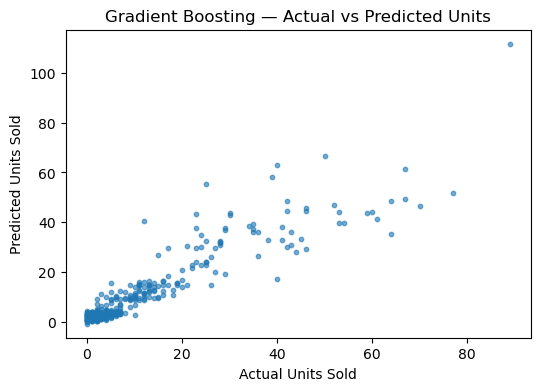

In [7]:
# 4) ML demand model (Gradient Boosting) — pooled with product dummies
df_ml = df.copy()
# One-hot for product
prod_dum = pd.get_dummies(df_ml["product"], prefix="product", drop_first=True)
df_ml = pd.concat([df_ml.drop(columns=["product"]), prod_dum], axis=1)

features = ["price", "competitor_price", "marketing_spend", "visibility_index", "unit_cost"] + list(prod_dum.columns)
target = "units_sold"

X = df_ml[features].values
y = df_ml[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

print("GBR R^2:", round(r2_score(y_test, y_pred), 3))
print("GBR MAE:", round(mean_absolute_error(y_test, y_pred), 2))

plt.figure()
plt.scatter(y_test, y_pred, s=10, alpha=0.6)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Gradient Boosting — Actual vs Predicted Units")
plt.show()


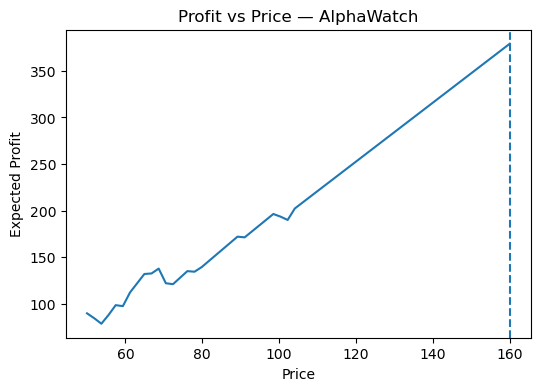

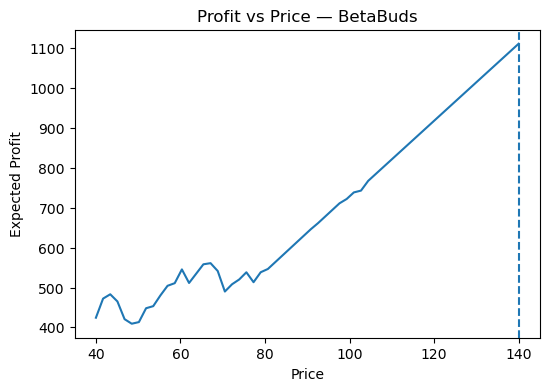

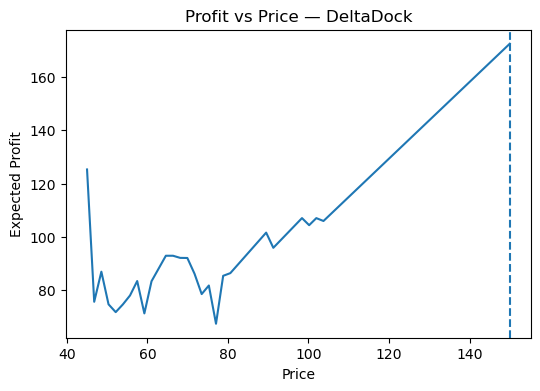

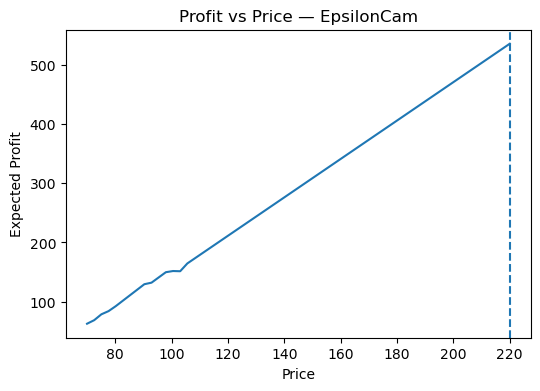

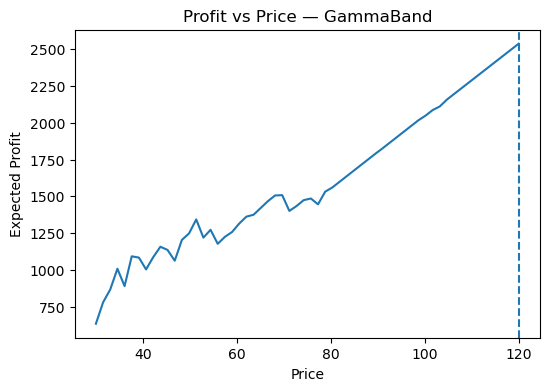

,product,unit_cost,optimal_price,expected_units,expected_profit,median_competitor_price
0,AlphaWatch,40,160.0,3.2,378.99,74.35
1,BetaBuds,25,140.0,9.7,1111.41,61.62
2,DeltaDock,30,150.0,1.4,172.47,66.55
3,EpsilonCam,55,220.0,3.3,536.26,90.89
4,GammaBand,18,120.0,24.9,2537.23,52.17


In [8]:

# 5) Profit-Optimal Price Search (per product)
# We will use the ML demand model to simulate demand across a price grid, then pick the price maximizing expected profit.
# profit(price) = (price - unit_cost) * predicted_units(price, ...)

def optimal_price_for_product(product_name, comp_price, marketing, visibility, unit_cost, price_min, price_max, steps=50):
    prices = np.linspace(price_min, price_max, steps)
    # construct feature matrix for this product at different prices
    rows = []
    for p in prices:
        row = {
            "price": p,
            "competitor_price": comp_price,
            "marketing_spend": marketing,
            "visibility_index": visibility,
            "unit_cost": unit_cost
        }
        for prod in prod_cols:
            row[prod] = 1.0 if prod.endswith(product_name) else 0.0
        rows.append(row)
    sim = pd.DataFrame(rows)[features]
    units = gbr.predict(sim.values).clip(min=0)
    profit = (prices - unit_cost) * units
    best_idx = int(np.argmax(profit))
    return prices[best_idx], units[best_idx], profit[best_idx], prices, units, profit

# product dummy columns
prod_cols = [c for c in df_ml.columns if c.startswith("product_")]

summary = []
price_ranges = {
    "AlphaWatch": (50, 160),
    "BetaBuds": (40, 140),
    "GammaBand": (30, 120),
    "DeltaDock": (45, 150),
    "EpsilonCam": (70, 220),
}

for p in sorted(df["product"].unique()):
    sub = df[df["product"] == p]
    comp_price = sub["competitor_price"].median()
    marketing = sub["marketing_spend"].median()
    visibility = sub["visibility_index"].median()
    unit_cost = sub["unit_cost"].iloc[0]
    pmin, pmax = price_ranges.get(p, (unit_cost*1.05, unit_cost+120))

    p_star, q_star, prof_star, prices, units, profit = optimal_price_for_product(
        p, comp_price, marketing, visibility, unit_cost, pmin, pmax, steps=60
    )
    summary.append({"product": p, "unit_cost": unit_cost, "optimal_price": round(float(p_star),2),
                    "expected_units": round(float(q_star),1), "expected_profit": round(float(prof_star),2),
                    "median_competitor_price": round(float(comp_price),2)})

    # plot profit vs price for each product
    plt.figure()
    plt.plot(prices, profit)
    plt.axvline(p_star, linestyle="--")
    plt.xlabel("Price")
    plt.ylabel("Expected Profit")
    plt.title(f"Profit vs Price — {p}")
    plt.show()

opt_df = pd.DataFrame(summary)
display(opt_df)


In [9]:

# 6) Business-friendly summary
print("==== Business Summary ====")
for _, row in opt_df.iterrows():
    print(f"- {row['product']}: set price around ${row['optimal_price']} (cost ${row['unit_cost']}), "
          f"expect ~{row['expected_units']} units/day → profit ≈ ${row['expected_profit']}. "
          f"(Competitor median: ${row['median_competitor_price']})")

print("\nNotes:")
print("- Elasticities (log-log) indicate how sensitive demand is to price changes (negative values).")
print("- The ML model simulates demand under different prices while holding competitor price, marketing, and visibility at typical levels.")
print("- You can re-run the optimal price search with your planned marketing budget or anticipated competitor price to do scenario planning.")


==== Business Summary ====
- AlphaWatch: set price around $160.0 (cost $40), expect ~3.2 units/day → profit ≈ $378.99. (Competitor median: $74.35)
- BetaBuds: set price around $140.0 (cost $25), expect ~9.7 units/day → profit ≈ $1111.41. (Competitor median: $61.62)
- DeltaDock: set price around $150.0 (cost $30), expect ~1.4 units/day → profit ≈ $172.47. (Competitor median: $66.55)
- EpsilonCam: set price around $220.0 (cost $55), expect ~3.3 units/day → profit ≈ $536.26. (Competitor median: $90.89)
- GammaBand: set price around $120.0 (cost $18), expect ~24.9 units/day → profit ≈ $2537.23. (Competitor median: $52.17)

Notes:
- Elasticities (log-log) indicate how sensitive demand is to price changes (negative values).
- The ML model simulates demand under different prices while holding competitor price, marketing, and visibility at typical levels.
- You can re-run the optimal price search with your planned marketing budget or anticipated competitor price to do scenario planning.
